# Notebook guide

This notebook is for exploratory data-pipeline checks.

## Usage notes
- Treat results as ad hoc diagnostics unless promoted to a script
- Re-run all cells after changing source queries or filters

Document any stable workflow in a Python module once confirmed.

In [1]:
import pandas as pd

df = pd.read_parquet("../../data/raw/daily_close_volume_screened_2016_2025.parquet")
prices = df[df["ticker"].isin(["VOO", "SPY"])].pivot(
    index="date", columns="ticker", values="close_price"
)
prices

ticker,SPY,VOO
date,,
2016-01-04,171.6635,157.3431
2016-01-05,171.6295,157.2496
2016-01-06,169.6208,155.2594
2016-01-07,165.0588,151.2195
2016-01-08,163.3866,149.7992
...,...,...
2025-12-24,689.5600,634.4100
2025-12-26,689.9100,634.6900
2025-12-29,687.3400,632.1500


<Axes: title={'center': 'VOO vs SPY – Daily Close Price'}, xlabel='date'>

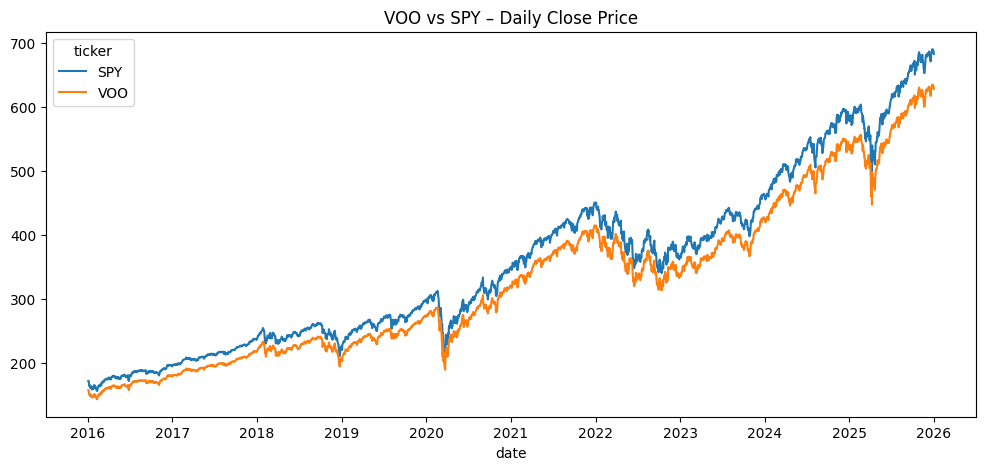

In [2]:
%matplotlib inline
prices.plot(figsize=(12, 5), title="VOO vs SPY – Daily Close Price")

In [3]:
prices.pct_change().dropna().corr()

ticker,SPY,VOO
ticker,,
SPY,1.000000,0.942917
VOO,0.942917,1.000000
